## Simulating Phylogenetic Trees using CTMCs

We will walk through a small example to simulate a phylogeny using the JC69 model. 

In this script, we will:

1) build a small rooted tree with branch lengths,
2) simulate sequence evolution under the JC69 CTMC,
3) print internal and leaf sequences,
4) compute pairwise Hamming distances among leaves,
5) plot the phylogenetic tree with sequences at the tips.


In [1]:
from __future__ import annotations

import argparse
from dataclasses import dataclass, field
from itertools import combinations
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np

In [2]:
## set up the data strcture

BASES = np.array(list("ACGT"))
STATE_TO_IDX = {b: i for i, b in enumerate(BASES)}


@dataclass
class Node:
    name: str
    branch_length: float = 0.0
    children: List["Node"] = field(default_factory=list)
    sequence: Optional[str] = None
    x: float = 0.0
    y: float = 0.0

    @property
    def is_leaf(self) -> bool:
        return len(self.children) == 0

In [3]:
## the transition matrix

def jc69_matrix(alpha: float, t: float) -> np.ndarray:
    """Transition matrix for the JC69 model over branch length t."""
    e = np.exp(-4.0 * alpha * t)
    P = np.full((4, 4), 0.25 - 0.25 * e)
    np.fill_diagonal(P, 0.25 + 0.75 * e)
    return P

In [4]:
## go along a branch and simulate all children 

def sample_child_sequence(parent_seq: str, alpha: float, t: float, rng: np.random.Generator) -> str:
    """Evolve a full sequence down one branch using sitewise independence."""
    P = jc69_matrix(alpha, t)
    child = []
    for base in parent_seq:
        probs = P[STATE_TO_IDX[base]]
        child.append(rng.choice(BASES, p=probs))
    return "".join(child)

In [5]:
## then iteratively generate all branches for the tree

def simulate_tree_sequences(root: Node, alpha: float, seq_length: int, rng: np.random.Generator) -> None:
    root.sequence = "".join(rng.choice(BASES, size=seq_length))

    def recurse(node: Node) -> None:
        for child in node.children:
            child.sequence = sample_child_sequence(node.sequence, alpha, child.branch_length, rng)
            recurse(child)

    recurse(root)

In [6]:
## collect all nodes/leaves

def collect_nodes(root: Node) -> List[Node]:
    nodes = []

    def recurse(node: Node):
        nodes.append(node)
        for child in node.children:
            recurse(child)

    recurse(root)
    return nodes


def collect_leaves(root: Node) -> List[Node]:
    return [node for node in collect_nodes(root) if node.is_leaf]

In [7]:
## compute pairwise distances, and some simplification for visualization

def pairwise_hamming(leaves: List[Node]) -> Dict[tuple, float]:
    out = {}
    for a, b in combinations(leaves, 2):
        mismatches = sum(x != y for x, y in zip(a.sequence, b.sequence))
        out[(a.name, b.name)] = mismatches / len(a.sequence)
    return out


def assign_layout(root: Node) -> None:
    """Simple deterministic layout: x is distance from root, y is leaf order average."""
    leaves = collect_leaves(root)
    leaf_y = {leaf.name: i for i, leaf in enumerate(leaves)}

    def recurse(node: Node, x_accum: float) -> float:
        node.x = x_accum
        if node.is_leaf:
            node.y = leaf_y[node.name]
            return node.y
        ys = [recurse(child, x_accum + child.branch_length) for child in node.children]
        node.y = sum(ys) / len(ys)
        return node.y

    recurse(root, 0.0)


def truncate_seq(seq: str, max_chars: int = 18) -> str:
    if len(seq) <= max_chars:
        return seq
    return seq[: max_chars - 3] + "..."

In [9]:
## plotting function for the tree

def plot_tree(root: Node, alpha: float):
    assign_layout(root)
    nodes = collect_nodes(root)
    leaves = collect_leaves(root)

    fig, ax = plt.subplots(figsize=(11, 6))

    for node in nodes:
        for child in node.children:
            ax.plot([node.x, child.x], [node.y, child.y], lw=2)
            ax.plot([child.x, child.x], [node.y, child.y], lw=2)
            midx = 0.5 * (node.x + child.x)
            midy = child.y + 0.1
            ax.text(midx, midy, f"t={child.branch_length:.2f}", fontsize=9, ha="center")

    for node in nodes:
        ax.scatter(node.x, node.y, s=70 if node.is_leaf else 50, zorder=3)
        label = f"{node.name}: {truncate_seq(node.sequence)}"
        if node.is_leaf:
            ax.text(node.x + 0.05, node.y, label, va="center", fontsize=10)
        else:
            ax.text(node.x - 0.03, node.y + 0.18, label, ha="right", fontsize=9)

    ax.set_title(f"JC69 simulation on a rooted tree (alpha={alpha})")
    ax.set_xlabel("Distance from root / branch-length scale")
    ax.set_ylabel("Taxa")
    ax.set_yticks(range(len(leaves)))
    ax.set_yticklabels([leaf.name for leaf in leaves])
    ax.set_ylim(-0.7, len(leaves) - 0.3)
    ax.invert_yaxis()  # top-to-bottom leaf order
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    #fig.savefig(out_path, dpi=180)
    #plt.close(fig)
    fig.show()


Now with utilities functions defined, we will simulate the tree and visualize.

In [10]:
## some code for building a simple demo 

def build_demo_tree() -> Node:
    """Fixed 4-taxon rooted tree for very simple demo."""
    return Node(
        name="root",
        children=[
            Node(
                name="internal_1",
                branch_length=0.50,
                children=[
                    Node(name="Taxon_A", branch_length=0.35),
                    Node(name="Taxon_B", branch_length=0.25),
                ],
            ),
            Node(
                name="internal_2",
                branch_length=0.70,
                children=[
                    Node(name="Taxon_C", branch_length=0.20),
                    Node(name="Taxon_D", branch_length=0.55),
                ],
            ),
        ],
    )


def print_report(root: Node) -> None:
    print("Simulated sequences by node")
    print("=" * 70)
    for node in collect_nodes(root):
        node_type = "leaf" if node.is_leaf else "internal"
        print(f"{node.name:12s} [{node_type:8s}]  {node.sequence}")

    leaves = collect_leaves(root)
    print("\nPairwise leaf Hamming distances")
    print("=" * 70)
    for (a, b), d in pairwise_hamming(leaves).items():
        print(f"{a:8s} vs {b:8s} : {d:.3f}")

In [11]:
## set up parameters

seed = 42
length = 40 # sequence length
alpha = 0.8 # rate parameter


Simulated sequences by node
root         [internal]  ATGCCTAGAAGTGTGTGATCGCATTGCTGCCAAGTATTCG
internal_1   [internal]  GCTTGACAAGGTCCGAACCGGTGCTTCCGACAGGTGGGAA
Taxon_A      [leaf    ]  GCTTGCCAAGCGTCAAACCGGGGAAAGCACAGGGCGGAAT
Taxon_B      [leaf    ]  TCCTGCCAATGCCCCGGCCGGTACATCCACCTGGTATGGA
internal_2   [internal]  CGTGCCCGCATTAGATCGTGATAAGCTTCTCCATAACTTG
Taxon_C      [leaf    ]  TTTGGCCACATGAGACCGCGGTAAACCTCTCCATCCCCTG
Taxon_D      [leaf    ]  CGTTCTAGGAAGTGTTCGAATTACGTGCCGGTCCAGTAAG

Pairwise leaf Hamming distances
Taxon_A  vs Taxon_B  : 0.550
Taxon_A  vs Taxon_C  : 0.675
Taxon_A  vs Taxon_D  : 0.775
Taxon_B  vs Taxon_C  : 0.675
Taxon_B  vs Taxon_D  : 0.800
Taxon_C  vs Taxon_D  : 0.750


/var/folders/l2/rhnr0zg573x6pc63ct4f3vd80000gn/T/ipykernel_50301/4037449624.py:37: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


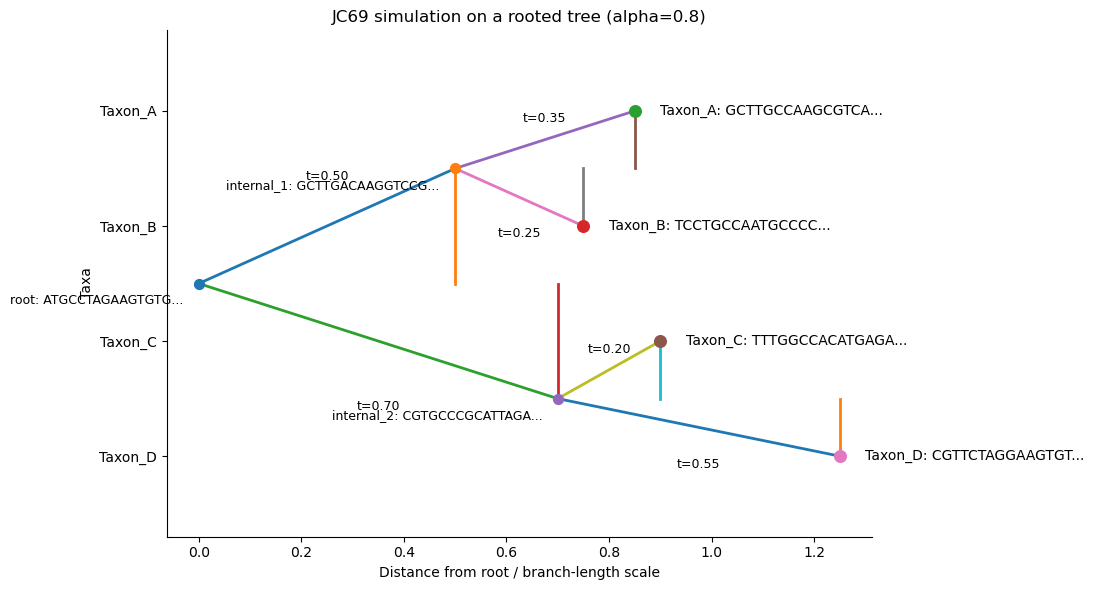

In [12]:
## main block to simulate the tree and plot

rng = np.random.default_rng(seed)
root = build_demo_tree()
simulate_tree_sequences(root, alpha=alpha, seq_length=length, rng=rng)
print_report(root)
plot_tree(root, alpha=alpha)